In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class CRNNnet(nn.Module):
    def __init__(self, *, inputLength = 30, kernelSize = 3, kindsOutput = 30):
        super().__init__()
        filterNum1 = 64
        filterNum2 = 32 
        self.layer1 = nn.Sequential(
            nn.Conv1d(100, filterNum1, kernelSize), # inputLength - kernelSize + 1 = 80 - 3 + 1 = 78
            nn.BatchNorm1d(filterNum1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernelSize, stride = 1) # 78 - 3 + 1 = 76
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(filterNum1, filterNum2, kernelSize), # 76 - 3 + 1 = 74
            nn.BatchNorm1d(filterNum2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernelSize, stride = 1) # 74 - 3 + 1 = 72
        )
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(22, kindsOutput)

        self.rnn = nn.GRU(
            input_size=32,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
        )
        # for p in self.rnn.parameters():
        #     nn.init.normal_(p, mean=0.0, std=0.001)   # 对参数进行初值化

        self.linear = nn.Linear(64, 100)
    
    def forward(self,x):
        x = x.to(torch.float32)
        x = self.layer1(x)
        x = self.layer2(x)
        # x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = self.dropout(x)
        x = x.permute(0,2,1)
        out, _ = self.rnn(x)  # [b, seq, h]
        out = self.linear(out)
        return out
       


In [2]:
# model = CRNNnet().to('cuda')
# from torchinfo import summary
# summary(model, input_size=[1,100,30])

In [30]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

eta00 = np.load('Main_Project_file/data/data/6000_1s_data_eta00.npy')
data = eta00[:,20,100:200]

# # 加载预训练的参数
# checkpoint = torch.load('model_parameters200.pth')

# # 将参数加载到模型中
# model.load_state_dict(checkpoint)




def show_result(time = 0):
    model = CRNNnet().to('cuda')

    # 加载预训练的参数
    checkpoint = torch.load('model_parameters1000.pth')

    # 将参数加载到模型中
    model.load_state_dict(checkpoint)
    
    X = data[5800:5830]
    X = np.expand_dims(X, axis=0)
    X_tensor = torch.Tensor(X).to('cuda').permute(0,2,1)
    pre = model(X_tensor)
    prediction_array = pre.cpu().detach().numpy()
    prediction = prediction_array[:,time,:].reshape(-1)
    
    actual = data[5830:5860]
    actual = actual[time,:]  

    x = np.linspace(1, 100, 100) 
    actual = interp1d(x, actual, kind='cubic')
    prediction = interp1d(x,prediction, kind='cubic')
    x_dense = np.linspace(1, 100, 1000)

    plt.figure(figsize=(10, 6))
    plt.plot(x_dense, actual(x_dense), '--', label='Actual')
    plt.plot(x_dense, prediction(x_dense), '-', label='Prediction')
    plt.legend()
    plt.title(f'time{time}')
    plt.xlabel('x (100 points)')
    plt.ylabel('Wave Height')
    plt.grid(True)
    plt.show()




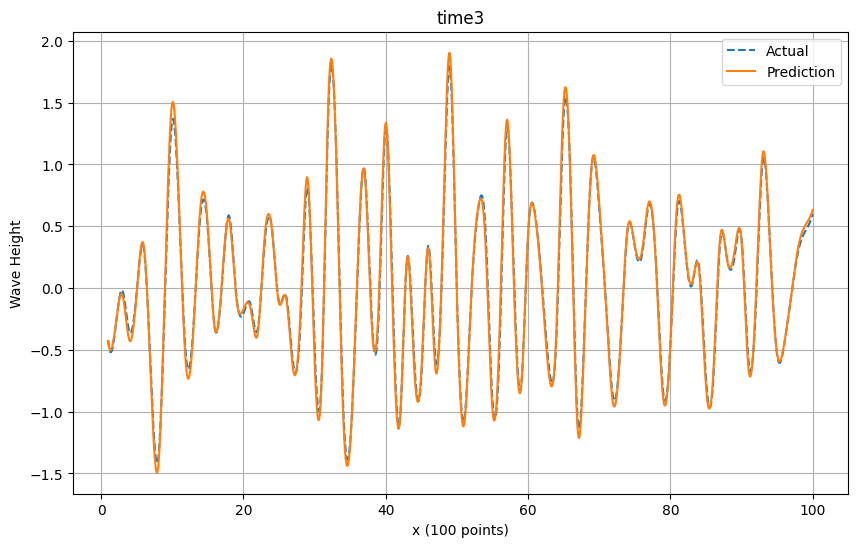

In [34]:
show_result(3)